In [9]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
file_path = r"datos_preprocesados_winsorizado.csv"

df = pd.read_csv(file_path)  

In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Aseguramos que el dataset esté ordenado por 'casa_id' y 'timestamp'
df.sort_values(['casa_id', 'timestamp'], inplace=True)

# (Si no existen aún) Generamos features temporales: 
# Nota: Estos campos pueden ya estar presentes del preprocesamiento, pero los incluimos para reforzar.
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek

# Crear lag features por cada casa
df['lag_1'] = df.groupby('casa_id')['consumo_kwh'].shift(1)   # consumo 1 hora anterior
df['lag_24'] = df.groupby('casa_id')['consumo_kwh'].shift(24)  # consumo a la misma hora del día anterior

# Eliminamos filas sin lag (al comienzo de la serie para cada casa)
df = df.dropna(subset=['lag_1', 'lag_24'])

print("Dataset con features y lag creado:")
print(df.head())


Dataset con features y lag creado:
    casa_id           timestamp  consumo_kwh  coste_euros  year  month  day  \
24       37 2017-06-01 01:00:00        0.512     0.076129  2017      6    1   
25       37 2017-06-01 02:00:00        0.247     0.034476  2017      6    1   
26       37 2017-06-01 03:00:00        0.168     0.022643  2017      6    1   
27       37 2017-06-01 04:00:00        0.171     0.025033  2017      6    1   
28       37 2017-06-01 05:00:00        0.146     0.023500  2017      6    1   

    hour  dayofweek  is_weekend  is_saturday   lag_1  lag_24  
24     1          3           0        False  0.6135   0.176  
25     2          3           0        False  0.5120   0.222  
26     3          3           0        False  0.2470   0.195  
27     4          3           0        False  0.1680   0.163  
28     5          3           0        False  0.1710   0.235  


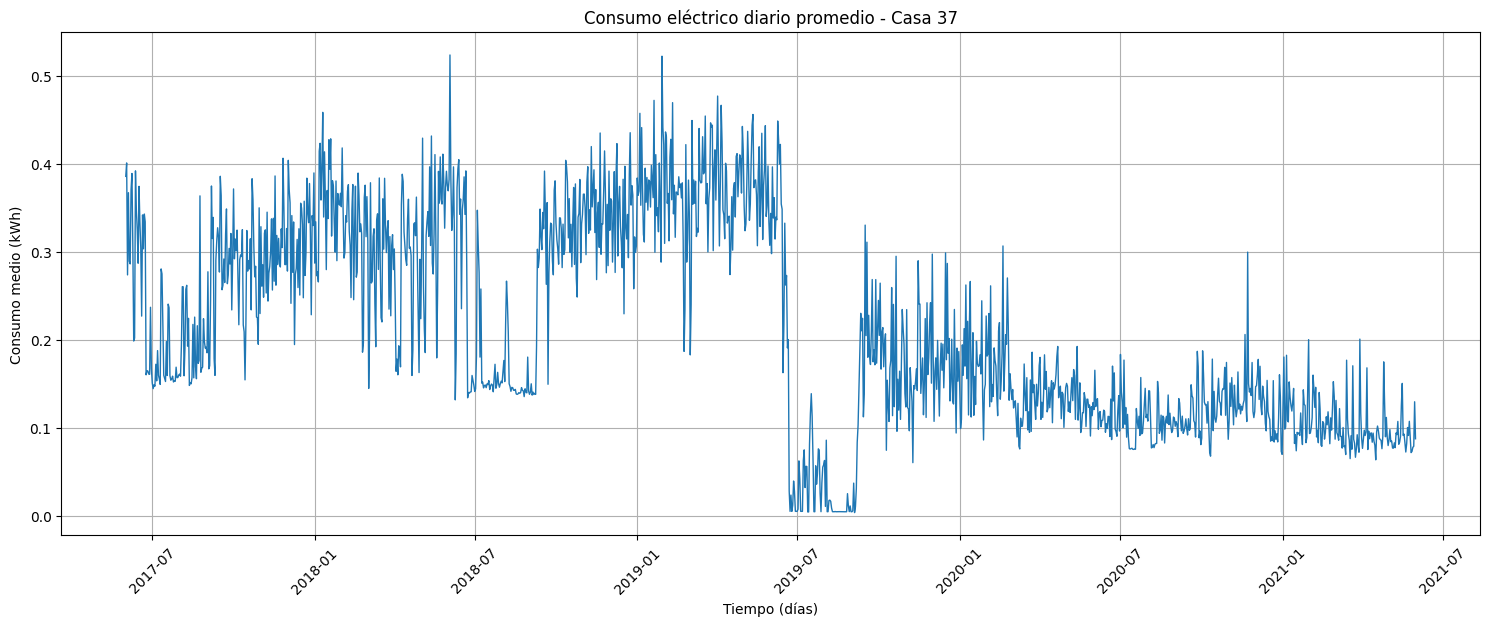

In [37]:
# Media diaria
casa_37_diaria = casa_37.set_index('timestamp').resample('D')['consumo_kwh'].mean()

plt.figure(figsize=(15,6))
plt.plot(casa_37_diaria.index, casa_37_diaria.values, linestyle='-', linewidth=1)

plt.title('Consumo eléctrico diario promedio - Casa 37')
plt.xlabel('Tiempo (días)')
plt.ylabel('Consumo medio (kWh)')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


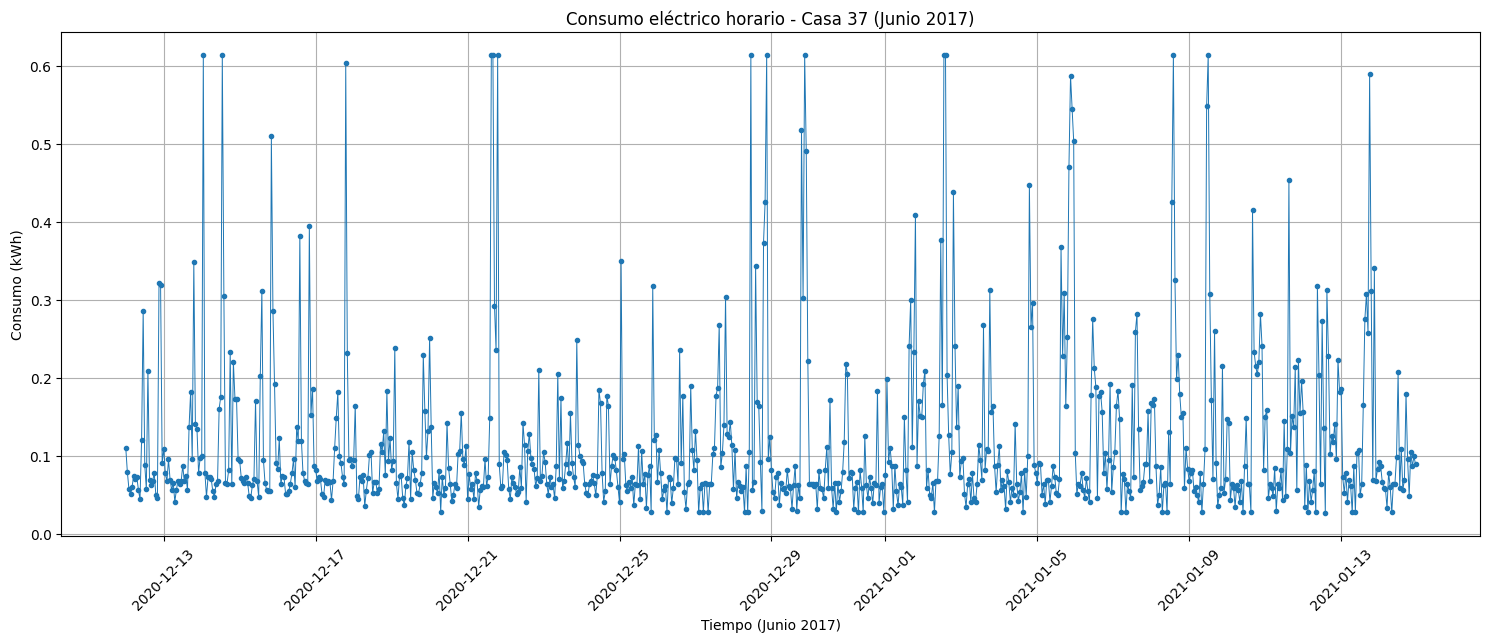

In [40]:
# Filtrar solo un mes (por ejemplo junio de 2017)
casa_37_junio = casa_37[(casa_37['timestamp'] >= '2020-12-12') & (casa_37['timestamp'] < '2021-01-15')]

plt.figure(figsize=(15,6))
plt.plot(casa_37_junio['timestamp'], casa_37_junio['consumo_kwh'], marker='.', linestyle='-', linewidth=0.7)

plt.title('Consumo eléctrico horario - Casa 37 (Junio 2017)')
plt.xlabel('Tiempo (Junio 2017)')
plt.ylabel('Consumo (kWh)')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


In [6]:
# Ordenamos globalmente por timestamp
df.sort_values('timestamp', inplace=True)

# Definimos el índice de corte (80% de los datos)
split_index = int(len(df) * 0.8)
df_train = df.iloc[:split_index]
df_test = df.iloc[split_index:]

print("Tamaño del conjunto de entrenamiento:", len(df_train))
print("Tamaño del conjunto de prueba:", len(df_test))


Tamaño del conjunto de entrenamiento: 2132735
Tamaño del conjunto de prueba: 533184


In [7]:
# Seleccionar las features para el modelo
features = ['hour', 'day', 'month', 'dayofweek', 'lag_1', 'lag_24']
target = 'consumo_kwh'

X_train = df_train[features]
y_train = df_train[target]
X_test = df_test[features]
y_test = df_test[target]

# Definimos el modelo XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Definimos el grid de hiperparámetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# Utilizamos una validación cruzada temporal
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=tscv,
                           scoring='neg_mean_absolute_error', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor MAE (negativo):", grid_search.best_score_)

# Evaluamos en el conjunto de test
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("MAE XGBoost:", mae)
print("RMSE XGBoost:", rmse)


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Mejor MAE (negativo): -0.07457459935876894
MAE XGBoost: 0.07588655177166652
RMSE XGBoost: 0.12018114991486487


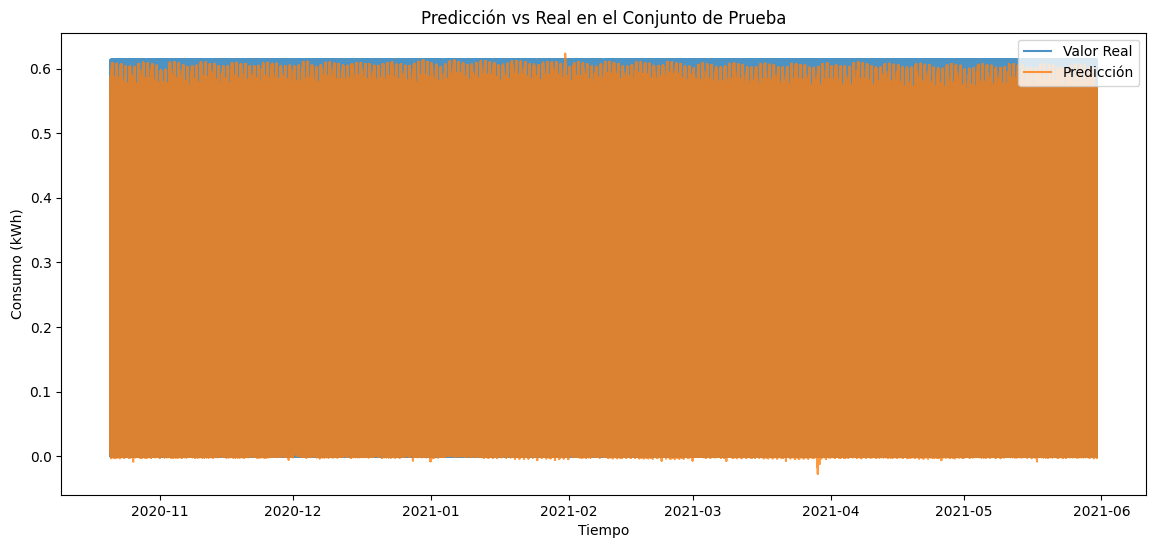

In [10]:
plt.figure(figsize=(14,6))
plt.plot(df_test['timestamp'], y_test, label='Valor Real', alpha=0.8)
plt.plot(df_test['timestamp'], y_pred, label='Predicción', alpha=0.8)
plt.xlabel('Tiempo')
plt.ylabel('Consumo (kWh)')
plt.title('Predicción vs Real en el Conjunto de Prueba')
plt.legend()
plt.show()


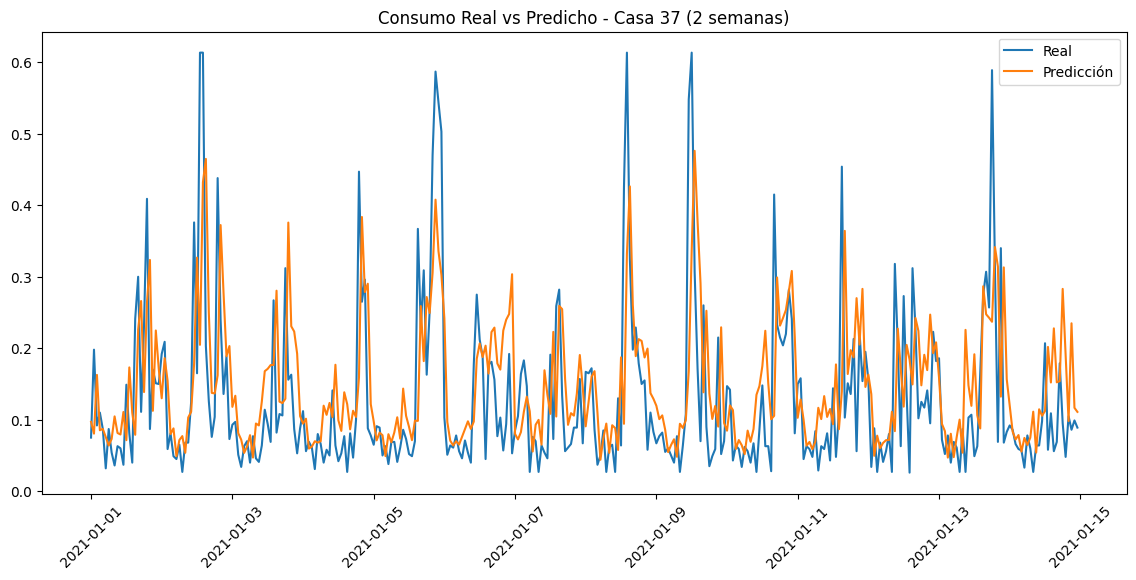

In [12]:
# Filtrar la casa 37 en el conjunto de test
df_test_37 = df_test[df_test['casa_id'] == 37]

# Elegir, por ejemplo, 2 semanas del test
fecha_inicial = '2021-01-01'
fecha_final = '2021-01-15'
df_test_37_period = df_test_37[(df_test_37['timestamp'] >= fecha_inicial) & 
                               (df_test_37['timestamp'] < fecha_final)]

# Predecimos sobre ese subset
X_test_37_period = df_test_37_period[features]
y_test_37_period = df_test_37_period[target]
y_pred_37_period = best_xgb.predict(X_test_37_period)

# Graficamos
plt.figure(figsize=(14,6))
plt.plot(df_test_37_period['timestamp'], y_test_37_period, label='Real')
plt.plot(df_test_37_period['timestamp'], y_pred_37_period, label='Predicción')
plt.xticks(rotation=45)
plt.title('Consumo Real vs Predicho - Casa 37 (2 semanas)')
plt.legend()
plt.show()


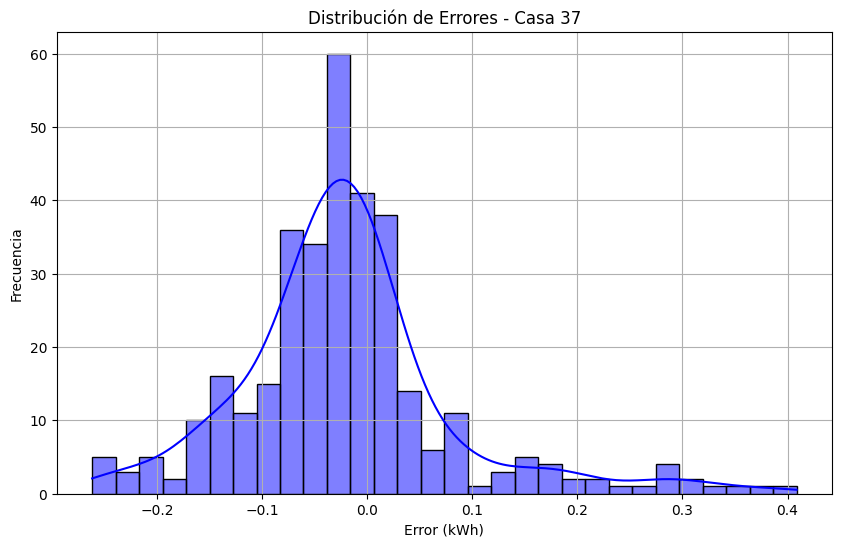

C:\Users\alexa\AppData\Local\Temp\ipykernel_8292\1544333679.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_37_period['error'] = df_test_37_period[target] - y_pred_37_period


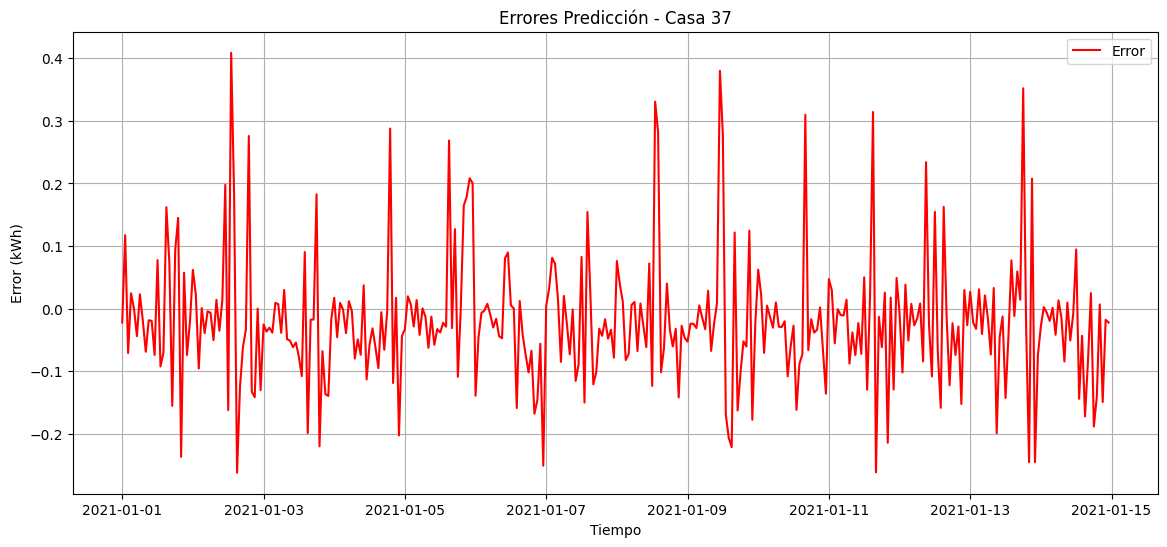

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Graficar la distribución de los errores
def graficar_distribucion_errores(df):
    plt.figure(figsize=(10, 6))
    sns.histplot(df['error'], kde=True, color='blue', bins=30)  # Histograma con curva de densidad
    plt.title(f"Distribución de Errores - Casa {id_casa}")
    plt.xlabel("Error (kWh)")
    plt.ylabel("Frecuencia")
    plt.grid()
    plt.show()

# Ejemplo de uso
graficar_distribucion_errores(df_test_37_period)
# Graficar la serie temporal de errores 
def graficar_errores_serie_temporal(df):
    plt.figure(figsize=(14, 6))
    plt.plot(df['timestamp'], df['error'], label='Error', color='red')
    plt.title(f"Errores Predicción - Casa {id_casa}")
    plt.xlabel("Tiempo")
    plt.ylabel("Error (kWh)")
    plt.legend()
    plt.grid()
    plt.show()
# Calcular errores
df_test_37_period['error'] = df_test_37_period[target] - y_pred_37_period
# Graficar errores
graficar_errores_serie_temporal(df_test_37_period)

In [31]:
print(df)

         casa_id           timestamp  consumo_kwh  coste_euros  year  month  \
149736     10713 2017-05-31 01:00:00        0.013     0.001933  2017      5   
2174471      638 2017-05-31 01:00:00        0.038     0.005650  2017      5   
2174472      638 2017-05-31 02:00:00        0.006     0.000837  2017      5   
149737     10713 2017-05-31 02:00:00        0.014     0.001954  2017      5   
149738     10713 2017-05-31 03:00:00        0.014     0.001887  2017      5   
...          ...                 ...          ...          ...   ...    ...   
922187      5640 2021-05-31 00:00:00        0.028     0.004429  2021      5   
911242      5558 2021-05-31 00:00:00        0.070     0.011072  2021      5   
900297      5551 2021-05-31 00:00:00        0.087     0.013761  2021      5   
1090822     7272 2021-05-31 00:00:00        0.555     0.087784  2021      5   
1679974    15502 2021-05-31 00:00:00        0.277     0.043813  2021      5   

         day  hour  dayofweek  is_weekend  is_satur

C:\Users\alexa\AppData\Local\Temp\ipykernel_8292\2382948030.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_37_period['y_pred'] = y_pred_37_period
C:\Users\alexa\AppData\Local\Temp\ipykernel_8292\2382948030.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_37_period['error'] = df_test_37_period['consumo_kwh'] - df_test_37_period['y_pred']


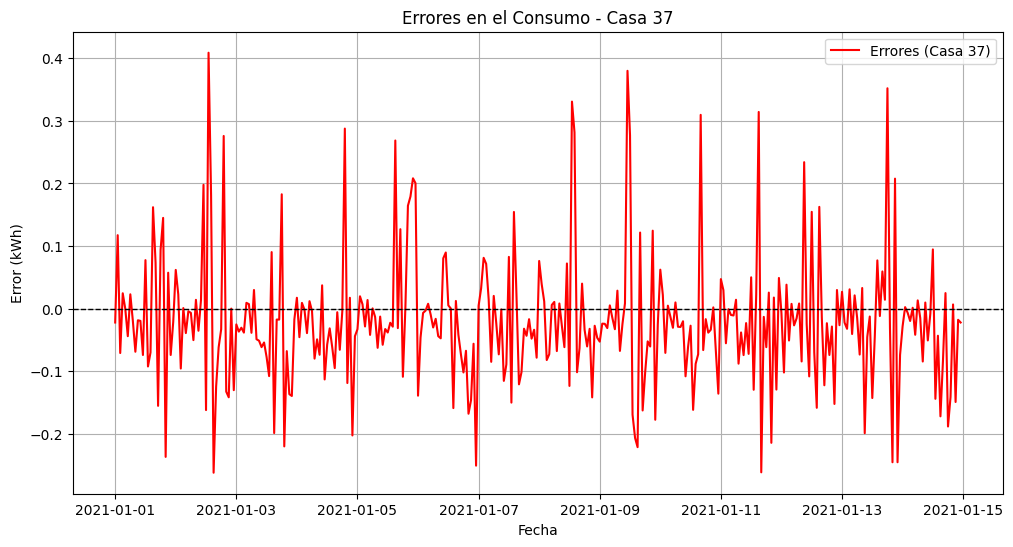

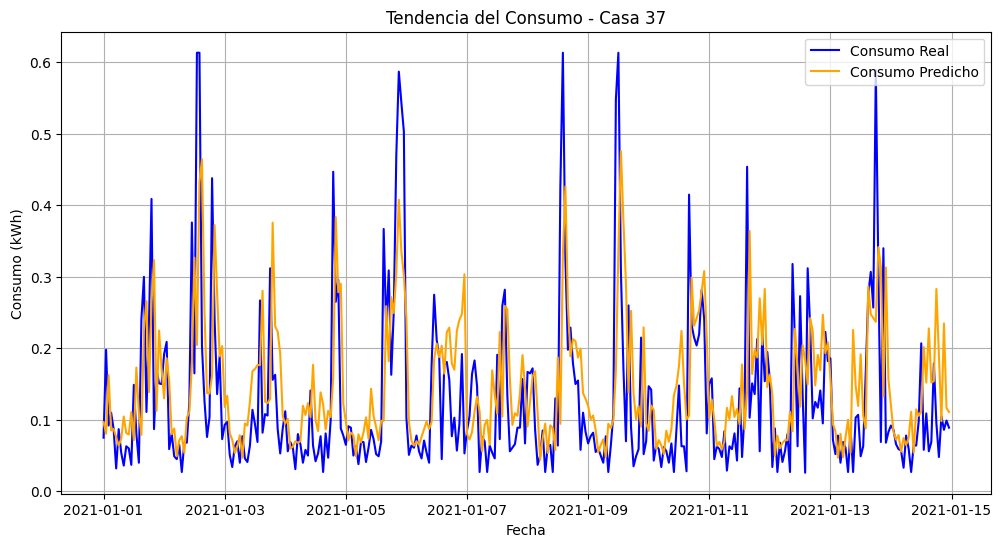

C:\Users\alexa\AppData\Local\Temp\ipykernel_8292\2382948030.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dia_semana'] = df['timestamp'].dt.dayofweek  # 0=Lunes, 6=Domingo
C:\Users\alexa\AppData\Local\Temp\ipykernel_8292\2382948030.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dia_semana', y='consumo_kwh', data=df, palette='Set2')


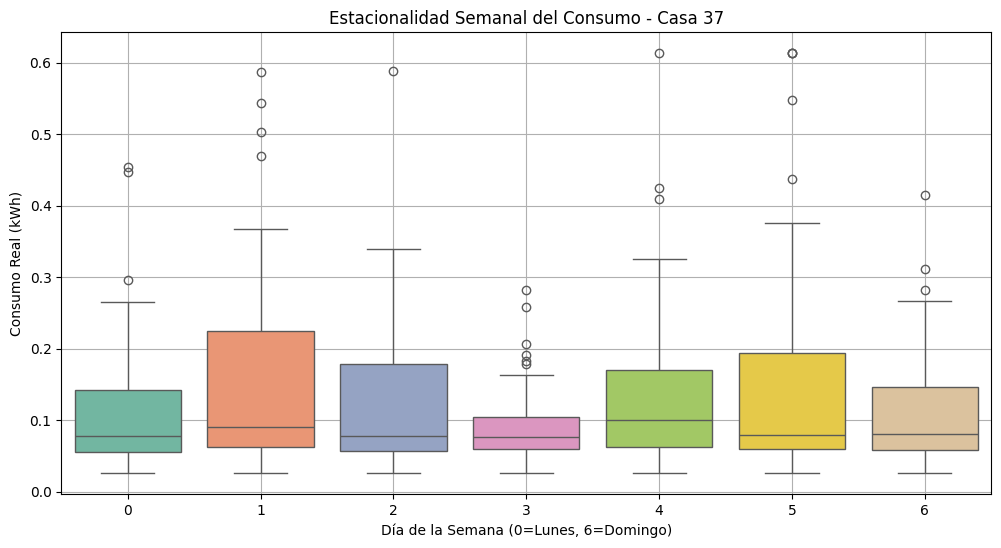

C:\Users\alexa\AppData\Local\Temp\ipykernel_8292\2382948030.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mes'] = df['timestamp'].dt.month
C:\Users\alexa\AppData\Local\Temp\ipykernel_8292\2382948030.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='mes', y='consumo_kwh', data=df, palette='Set3')


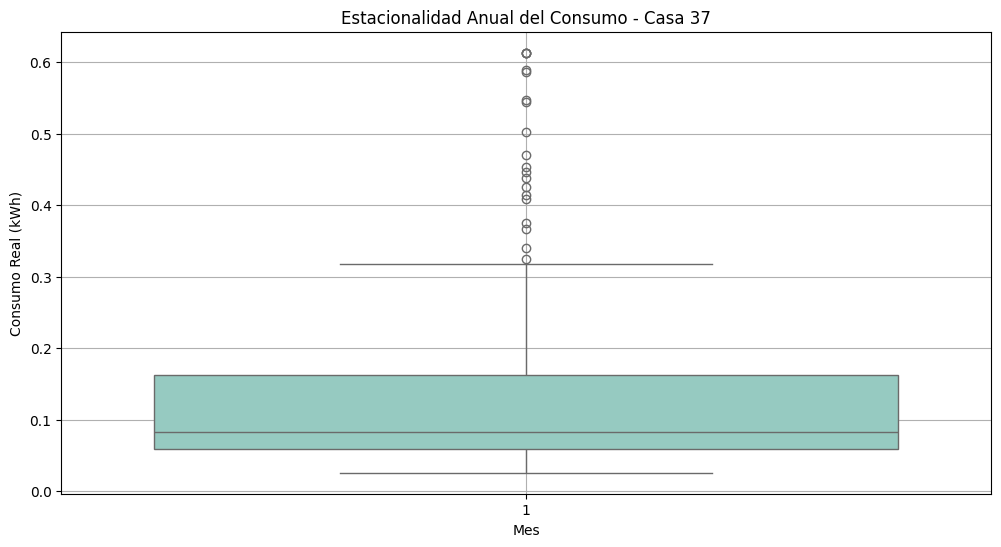

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

id_casa = 37  # ID de la casa a analizar
# Predecimos sobre ese subset
X_test_37_period = df_test_37_period[features]
y_test_37_period = df_test_37_period[target]
y_pred_37_period = best_xgb.predict(X_test_37_period)

# Agregar las predicciones al DataFrame de prueba
df_test_37_period['y_pred'] = y_pred_37_period

# Calcular los errores (diferencia entre consumo real y predicho)
df_test_37_period['error'] = df_test_37_period['consumo_kwh'] - df_test_37_period['y_pred']

# Graficar los errores para la casa específica
def graficar_errores_casa(df):
    plt.figure(figsize=(12, 6))
    plt.plot(df['timestamp'], df['error'], label=f'Errores (Casa {id_casa})', color='red')
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title(f"Errores en el Consumo - Casa {id_casa}")
    plt.xlabel("Fecha")
    plt.ylabel("Error (kWh)")
    plt.legend()
    plt.grid()
    plt.show()

# Graficar tendencia general para la casa específica
def graficar_tendencia_casa(df):
    plt.figure(figsize=(12, 6))
    plt.plot(df['timestamp'], df['consumo_kwh'], label='Consumo Real', color='blue')
    plt.plot(df['timestamp'], df['y_pred'], label='Consumo Predicho', color='orange')
    plt.title(f"Tendencia del Consumo - Casa {id_casa}")
    plt.xlabel("Fecha")
    plt.ylabel("Consumo (kWh)")
    plt.legend()
    plt.grid()
    plt.show()

# Graficar estacionalidad semanal para la casa específica
def graficar_estacionalidad_semanal(df):
    df['dia_semana'] = df['timestamp'].dt.dayofweek  # 0=Lunes, 6=Domingo
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='dia_semana', y='consumo_kwh', data=df, palette='Set2')
    plt.title(f"Estacionalidad Semanal del Consumo - Casa {id_casa}")
    plt.xlabel("Día de la Semana (0=Lunes, 6=Domingo)")
    plt.ylabel("Consumo Real (kWh)")
    plt.grid()
    plt.show()

# Graficar estacionalidad anual para la casa específica
def graficar_estacionalidad_anual(df):
    df['mes'] = df['timestamp'].dt.month
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='mes', y='consumo_kwh', data=df, palette='Set3')
    plt.title(f"Estacionalidad Anual del Consumo - Casa {id_casa}")
    plt.xlabel("Mes")
    plt.ylabel("Consumo Real (kWh)")
    plt.grid()
    plt.show()

# Ejemplo de uso
# Graficar errores para la casa específica
graficar_errores_casa(df_test_37_period)

# Graficar tendencia para la casa específica
graficar_tendencia_casa(df_test_37_period)

# Graficar estacionalidad semanal
graficar_estacionalidad_semanal(df_test_37_period)

# Graficar estacionalidad anual
graficar_estacionalidad_anual(df_test_37_period)